# 03 · Fotos, perfil del vendedor, texto combinado e hiperparámetros

El modelo del `02_features.ipynb` llega a **93,8% en la validación** y **0,93809 en Kaggle**. Este notebook prueba cuatro ideas para mejorarlo y mide cuánto aporta cada una con **la misma validación cruzada** (5 particiones estratificadas, `random_state=42`):

1. **Las fotos**: qué tamaño tienen y cuándo se subieron.
2. **Otros campos del JSON** que todavía no se usaban (estado de la publicación, moneda, precio comparado con su categoría...).
3. **El perfil del vendedor**: cómo publica (precio medio, en cuántas categorías, si usa fotos de catálogo...).
4. **Más texto**: además del título, la garantía y los atributos.

Después se ajustan los **hiperparámetros** de LightGBM, se mira la **importancia de las features** y se arma la submission.

**Cómo leer los resultados:** entre una partición y otra la nota varía alrededor de ±0,001. Por eso una mejora menor a ~0,001 se trata como **ruido** y no justifica complicar el modelo.

## 0. Datos y features del notebook 02 (sin cambios)

Esta celda repite lo del `02_features.ipynb` tal cual: carga, las 16 features del baseline, las 43 extra y el *target encoding*. Se copia para que este notebook corra solo.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier

train = pd.read_json("data/train_data.jsonlines", lines=True, keep_default_dates=False)
test  = pd.read_json("data/test_data.jsonlines",  lines=True, keep_default_dates=False)
y = (train["condition"] == "used").astype(int).values   # 1 = usado, 0 = nuevo
todo = pd.concat([train.drop(columns="condition"), test], ignore_index=True)
N_TRAIN = len(train)

def g(d, k):
    return d.get(k) if isinstance(d, dict) else None

def armar_features(df):
    X = pd.DataFrame(index=df.index)
    for c in ["price", "base_price", "initial_quantity", "sold_quantity", "available_quantity"]:
        X[c] = df[c]
    X["accepts_mercadopago"] = df["accepts_mercadopago"].astype(int)
    X["automatic_relist"]    = df["automatic_relist"].astype(int)
    X["free_shipping"] = df["shipping"].apply(lambda s: int(bool(g(s, "free_shipping"))))
    X["local_pick_up"] = df["shipping"].apply(lambda s: int(bool(g(s, "local_pick_up"))))
    X["n_pictures"]    = df["pictures"].apply(len)
    X["n_variations"]  = df["variations"].apply(len)
    X["n_attributes"]  = df["attributes"].apply(len)
    X["has_warranty"]  = df["warranty"].notna().astype(int)
    X["listing_type_id"] = df["listing_type_id"]
    X["buying_mode"]     = df["buying_mode"]
    X["shipping_mode"]   = df["shipping"].apply(lambda s: g(s, "mode"))
    return X

def armar_features_extra(df):
    X = pd.DataFrame(index=df.index)
    X["n_pagos"] = df["non_mercado_pago_payment_methods"].apply(len)
    pagos = df["non_mercado_pago_payment_methods"].apply(lambda L: {d.get("id") for d in L})
    for p in ["MLATB", "MLAWC", "MLAMO", "MLAOT", "MLAMC", "MLAVE", "MLAMS"]:
        X["pago_" + p] = pagos.apply(lambda s: int(p in s))
    X["n_tags"] = df["tags"].apply(len)
    for t in ["dragged_bids_and_visits", "good_quality_thumbnail", "dragged_visits",
              "free_relist", "poor_quality_thumbnail"]:
        X["tag_" + t] = df["tags"].apply(lambda L: int(t in L))
    X["tiene_sub_status"]      = df["sub_status"].apply(len)
    X["tiene_video"]           = df["video_id"].notna().astype(int)
    X["tiene_tienda_oficial"]  = df["official_store_id"].notna().astype(int)
    X["tiene_precio_original"] = df["original_price"].notna().astype(int)
    X["tiene_parent"]          = df["parent_item_id"].notna().astype(int)
    X["n_descripciones"]       = df["descriptions"].apply(len)
    X["dif_precio_base"] = df["price"] - df["base_price"]
    X["precio_redondo"]  = (df["price"] % 10 == 0).astype(int)
    X["duracion_dias"] = (df["stop_time"] - df["start_time"]) / 86_400_000
    creado = pd.to_datetime(df["date_created"], utc=True)
    actualizado = pd.to_datetime(df["last_updated"], utc=True)
    X["dias_desde_2013"] = (creado - pd.Timestamp("2013-01-01", tz="UTC")).dt.total_seconds() / 86400
    X["horas_hasta_update"] = (actualizado - creado).dt.total_seconds() / 3600
    titulo = df["title"].str.lower()
    X["largo_titulo"] = df["title"].str.len()
    for w in ["usad", "nuev", "original", "impecable", "excelente", "estado",
              "garant", "sin uso", "oferta", "import"]:
        X["titulo_" + w.replace(" ", "_")] = titulo.str.contains(w).astype(int)
    garantia = df["warranty"].fillna("").str.lower()
    X["largo_garantia"]   = garantia.str.len()
    X["garantia_sin"]     = garantia.str.contains("sin garant").astype(int)
    X["garantia_nuevo"]   = garantia.str.contains("nuev").astype(int)
    X["garantia_fabrica"] = garantia.str.contains("fabric").astype(int)
    X["state"] = df["seller_address"].apply(lambda a: g(g(a, "state"), "name"))
    X["vendedor_n_items"]  = df["seller_id"].map(todo["seller_id"].value_counts()).values
    X["categoria_n_items"] = df["category_id"].map(todo["category_id"].value_counts()).values
    return X

def target_encoding(clave_train, y_train, clave_test, suavizado=10):
    prior = y_train.mean()
    def tabla_proporciones(claves, ys):
        t = pd.DataFrame({"k": np.asarray(claves), "y": ys}).groupby("k")["y"].agg(["sum", "count"])
        return (t["sum"] + suavizado * prior) / (t["count"] + suavizado)
    enc_train = np.full(len(clave_train), prior)
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for idx_a, idx_b in kf.split(clave_train, y_train):
        tabla = tabla_proporciones(clave_train.iloc[idx_a], y_train[idx_a])
        enc_train[idx_b] = clave_train.iloc[idx_b].map(tabla).fillna(prior).values
    tabla = tabla_proporciones(clave_train, y_train)
    enc_test = clave_test.map(tabla).fillna(prior).values
    return enc_train, enc_test

BASE  = list(armar_features(todo.head(1)).columns)
EXTRA = list(armar_features_extra(todo.head(1)).columns)
print(train.shape, test.shape, f"{len(BASE)} base + {len(EXTRA)} extra")

(70000, 45) (30000, 44) 16 base + 43 extra


## 1. Features nuevas

### 1.1 Las fotos

Cada foto trae su tamaño máximo (`max_size`, por ejemplo `"1200x900"`). La proporción de usados cambia muchísimo según el tamaño de la **primera foto**:

In [2]:
tamanio = train["pictures"].apply(lambda L: L[0]["max_size"] if L else "sin foto")
tabla = pd.DataFrame({"tamaño primera foto": tamanio, "usado": y}).groupby("tamaño primera foto")["usado"].agg(["mean", "count"])
tabla.columns = ["proporción de usados", "ítems"]
tabla.sort_values("ítems", ascending=False).head(10).round(2)

,proporción de usados,ítems
tamaño primera foto,,
1200x900,0.65,10904
900x1200,0.73,7131
640x480,0.70,1640
1200x675,0.62,1472
500x500,0.05,1259
480x640,0.87,1125
675x1200,0.63,1090
1200x1200,0.21,792
800x800,0.02,721


- **4:3 o 3:4** (1200x900, 900x1200, 640x480, 480x640): entre 65% y 87% usados. Es el formato de la **cámara de un celular**: un particular que vende algo propio le saca una foto.
- **Cuadradas** (500x500, 1200x1200): entre 5% y 21% usados. Son **fotos de catálogo** del fabricante, las que usa una tienda.

Además, el `id` de cada foto termina con el **mes y año en que se subió**: `"4196-MLA4083767684_042012"` → abril de 2012. Si la publicación es de 2015 y la foto de 2012, es una publicación vieja que se volvió a lanzar.

Features que salen de acá: ancho, alto, proporción y área de la primera foto; qué parte de las fotos son cuadradas, 4:3 o verticales; cuántos meses antes de la publicación se subió la foto más vieja.

In [3]:
def dimensiones(s):
    # "1200x900" -> (1200, 900); si viene mal formado, (nan, nan)
    try:
        ancho, alto = s.split("x")
        return int(ancho), int(alto)
    except Exception:
        return np.nan, np.nan

def features_fotos(df):
    X = pd.DataFrame(index=df.index)
    primera = df["pictures"].apply(lambda L: dimensiones(L[0]["max_size"]) if L else (np.nan, np.nan))
    X["foto_ancho"]   = primera.str[0]
    X["foto_alto"]    = primera.str[1]
    X["foto_aspecto"] = X["foto_ancho"] / X["foto_alto"]
    X["foto_area"]    = X["foto_ancho"] * X["foto_alto"]

    todas = df["pictures"].apply(lambda L: [dimensiones(p["max_size"]) for p in L])
    X["fotos_cuadradas"] = todas.apply(lambda L: np.mean([w == h for w, h in L]) if L else np.nan)
    X["fotos_4_3"]       = todas.apply(lambda L: np.mean([max(w, h) * 3 == min(w, h) * 4 for w, h in L]) if L else np.nan)
    X["fotos_vertical"]  = todas.apply(lambda L: np.mean([h > w for w, h in L]) if L else np.nan)
    X["fotos_area_max"]  = todas.apply(lambda L: max(w * h for w, h in L) if L else np.nan)

    # mes de subida de cada foto, a partir del final del id: _MMAAAA
    def meses_fotos(L):
        meses = []
        for p in L:
            m = re.search(r"_(\d{2})(\d{4})$", p["id"])
            if m:
                meses.append(int(m.group(2)) * 12 + int(m.group(1)))
        return meses
    meses = df["pictures"].apply(meses_fotos)
    creado = pd.to_datetime(df["date_created"], utc=True)
    X["foto_meses_antes"] = (creado.dt.year * 12 + creado.dt.month) - meses.apply(lambda L: min(L) if L else np.nan)
    X["foto_tiene_fecha"] = meses.apply(lambda L: int(len(L) > 0))
    X["fotos_distintas"]  = df["pictures"].apply(lambda L: len({p["id"] for p in L}))
    return X

### 1.2 Otros campos del JSON

- `status`: las publicaciones **pausadas** tienen 31% de usados contra 47% de las activas.
- Moneda en **dólares** (62% usados), si participa de **ofertas** (`deal_ids`, casi todas nuevas), si tiene **producto de catálogo**.
- **Precio comparado con su categoría**: logaritmo del precio menos la mediana de su categoría. Un usado suele estar más barato que lo normal para lo que es.
- Vendidos sobre cantidad inicial, si se publicó **una sola unidad** (típico de un particular), cuántos atributos tienen las variantes, hora y día de la semana en que se publicó.

La mediana por categoría se calcula sobre train + test: no usa la respuesta, solo los precios.

In [4]:
def features_otros(df):
    X = pd.DataFrame(index=df.index)
    X["status"]         = df["status"]
    X["usd"]            = (df["currency_id"] == "USD").astype(int)
    X["n_deals"]        = df["deal_ids"].apply(len)
    X["tiene_catalogo"] = df["catalog_product_id"].notna().astype(int)
    X["log_precio"]     = np.log1p(df["price"])
    mediana_categoria = np.log1p(df["price"]).groupby(df["category_id"]).transform("median")
    X["precio_vs_categoria"]    = X["log_precio"] - mediana_categoria
    X["vendidos_sobre_inicial"] = df["sold_quantity"] / df["initial_quantity"].clip(lower=1)
    X["cant_inicial_1"]         = (df["initial_quantity"] == 1).astype(int)
    X["n_attr_variaciones"]     = df["variations"].apply(lambda L: sum(len(v.get("attribute_combinations") or []) for v in L))
    creado = pd.to_datetime(df["date_created"], utc=True)
    X["hora_creado"] = creado.dt.hour
    X["dia_semana"]  = creado.dt.dayofweek
    return X

### 1.3 Perfil del vendedor

El *target encoding* del 02 resume **qué vendió** cada vendedor (proporción de usados). Estas features describen **cómo publica**, sin mirar la respuesta: precio medio y su dispersión, en cuántas categorías y ciudades publica, cuántas unidades pone por publicación, qué proporción de sus publicaciones son *gold*, tienen garantía, están pausadas o usan foto cuadrada, y cuántos días hay entre su primera y su última publicación.

Una tienda publica muchas unidades, en pocas categorías, con fotos de catálogo y garantía. Un particular, una unidad, en categorías variadas, con fotos de celular.

Como no usan `condition`, se pueden calcular sobre train + test juntos sin *leakage* (igual que los conteos del 02). Sirven también para los vendedores que **no aparecen en train** (el 28% de test), donde el *target encoding* no sabe nada.

In [5]:
def features_vendedor(df):
    X = pd.DataFrame(index=df.index)
    vendedor = df["seller_id"]
    log_precio = np.log1p(df["price"])
    primera_cuadrada = df["pictures"].apply(lambda L: float(np.equal(*dimensiones(L[0]["max_size"]))) if L else np.nan)
    ciudad = df["seller_address"].apply(lambda a: g(g(a, "city"), "name"))
    creado = pd.to_datetime(df["date_created"], utc=True)

    X["vend_precio_medio"]       = log_precio.groupby(vendedor).transform("mean")
    X["vend_precio_std"]         = log_precio.groupby(vendedor).transform("std")
    X["vend_n_categorias"]       = df.groupby("seller_id")["category_id"].transform("nunique")
    X["vend_cant_inicial_media"] = df["initial_quantity"].groupby(vendedor).transform("mean")
    X["vend_prop_gold"]          = df["listing_type_id"].str.startswith("gold").groupby(vendedor).transform("mean")
    X["vend_prop_garantia"]      = df["warranty"].notna().groupby(vendedor).transform("mean")
    X["vend_n_fotos_media"]      = df["pictures"].apply(len).groupby(vendedor).transform("mean")
    X["vend_prop_foto_cuadrada"] = primera_cuadrada.groupby(vendedor).transform("mean")
    X["vend_n_ciudades"]         = ciudad.groupby(vendedor).transform("nunique")
    X["vend_dias_actividad"]     = creado.groupby(vendedor).transform(lambda t: (t.max() - t.min()).days)
    X["vend_prop_paused"]        = (df["status"] == "paused").groupby(vendedor).transform("mean")
    return X

### 1.4 Armado de la tabla de features

Todo se calcula una sola vez sobre `todo` (train + test) y después se separa. `CAT` son las columnas de texto que LightGBM trata como categóricas; se agrega `status`.

In [6]:
X_todo = pd.concat([armar_features(todo), armar_features_extra(todo),
                    features_fotos(todo), features_otros(todo), features_vendedor(todo)], axis=1)
X_train = X_todo.iloc[:N_TRAIN].reset_index(drop=True)
X_test  = X_todo.iloc[N_TRAIN:].reset_index(drop=True)

FOTOS    = list(features_fotos(todo.head(3)).columns)
OTROS    = list(features_otros(todo.head(3)).columns)
VENDEDOR = list(features_vendedor(todo.head(3)).columns)
CAT = ["listing_type_id", "buying_mode", "shipping_mode", "state", "status"]
print(f"{len(FOTOS)} de fotos, {len(OTROS)} otros, {len(VENDEDOR)} de vendedor  ->  total {X_train.shape[1]} columnas")

11 de fotos, 11 otros, 11 de vendedor  ->  total 92 columnas


## 2. Texto: probabilidad de usado según lo que está escrito

En el 02, un modelo **TF-IDF + regresión logística** leía el **título** y su probabilidad entraba como feature. Acá se generaliza a cualquier texto con `prob_texto`, y se prueban tres variantes:

- **Título con n-gramas de caracteres** (`analyzer="char_wb"`, pedazos de 2 a 5 letras): reconoce raíces y errores de tipeo ("usad", "usdo", "nuevoo").
- **Garantía** sola, con su propio modelo.
- **Texto combinado**: título + garantía + atributos (por ejemplo `GENDER=Mujer`) en un solo texto. Así el modelo ve todo lo escrito junto.

Igual que en el 02, la probabilidad se calcula **fuera de fold** en train y con todo train para test.

**Detalle de reproducibilidad:** `cross_val_predict` se usa **sin** `n_jobs`. Probé paralelizarlo y la regresión logística da resultados levemente distintos (hasta 0,04 en algunos ítems), lo que cambia unas 250 predicciones finales. Sin paralelizar, el resultado sale idéntico cada vez.

In [7]:
def prob_texto(textos_train, y_train, textos_test, vectorizador=None):
    if vectorizador is None:
        vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    modelo = make_pipeline(vectorizador, LogisticRegression(max_iter=3000, C=4))
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    p_train = cross_val_predict(modelo, textos_train, y_train, cv=kf, method="predict_proba")[:, 1]
    modelo.fit(textos_train, y_train)
    p_test = modelo.predict_proba(textos_test)[:, 1]
    return p_train, p_test

def vectorizador_caracteres():
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=3, sublinear_tf=True, max_features=300_000)

garantia_txt = todo["warranty"].fillna("sin_dato").astype(str)
atributos_txt = todo["attributes"].apply(lambda L: " ".join(f"{a.get('id')}={a.get('value_name')}" for a in L))
texto_combinado = todo["title"] + " || " + garantia_txt + " || " + atributos_txt
ciudad = todo["seller_address"].apply(lambda a: (g(g(a, "city"), "name") or "").strip().lower())

print(texto_combinado.iloc[2][:300])

Remera Manga Larga Talle S Marca Stone Caladita Hermosa || sin_dato || GENDER=Mujer Season=All-Season


## 3. Validación

Misma partición que el 02. Las features que **usan la respuesta** (target encoding y probabilidades de texto) se recalculan **adentro de cada partición**, solo con las 4 de entrenamiento, para no inflar la nota.

**Para que sea rápido:** esas piezas dependen solo de qué filas caen en cada partición, no de qué features usa LightGBM. Entonces se calculan **una vez por partición**, se guardan en `piezas`, y cada experimento las reutiliza. El resultado es idéntico a recalcularlas cada vez.

`piezas[f]` es un diccionario con, para la partición `f`, los valores de entrenamiento y de validación de cada pieza. La posición `5` guarda las del modelo final (todo train → test).

Se agrega una pieza más para probar: *target encoding* de la **ciudad** del vendedor.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
PARTICIONES = list(cv.split(X_train, y)) + [(np.arange(N_TRAIN), np.arange(N_TRAIN, len(todo)))]   # la última: train -> test

CLAVES = {"te_seller_id": todo["seller_id"], "te_category_id": todo["category_id"], "te_ciudad": ciudad}
TEXTOS = {
    "prob_titulo":       (todo["title"],    None),
    "prob_titulo_char":  (todo["title"],    vectorizador_caracteres),
    "prob_garantia":     (garantia_txt,     None),
    "prob_combinado":    (texto_combinado,  None),
}

def calcular_piezas(idx_a, idx_b, nombres):
    # idx_a: filas de entrenamiento, idx_b: filas a predecir (posiciones en `todo`)
    out = {}
    for n in nombres:
        if n in CLAVES:
            clave = CLAVES[n]
            out[n] = target_encoding(clave.iloc[idx_a].reset_index(drop=True), y[idx_a],
                                     clave.iloc[idx_b].reset_index(drop=True))
        else:
            texto, vect = TEXTOS[n]
            out[n] = prob_texto(texto.iloc[idx_a].reset_index(drop=True), y[idx_a],
                                texto.iloc[idx_b].reset_index(drop=True), vect() if vect else None)
    return out

def alinear_categorias(A, B):
    # las categorías de B (validación o test) tienen que ser las mismas que las de A (entrenamiento)
    for c in [c for c in CAT if c in A.columns]:
        cats = pd.Categorical(A[c]).categories
        A[c] = pd.Categorical(A[c], categories=cats)
        B[c] = pd.Categorical(B[c].where(B[c].isin(cats)), categories=cats)
    return A, B

def armar_conjunto(f, columnas, nombres_piezas):
    # f = número de partición (0-4 validación, 5 = modelo final)
    idx_a, idx_b = PARTICIONES[f]
    A = X_todo.iloc[idx_a][columnas].reset_index(drop=True)
    B = X_todo.iloc[idx_b][columnas].reset_index(drop=True)
    for n in nombres_piezas:
        A[n], B[n] = piezas[f][n]
    return alinear_categorias(A, B)

PARAMS_02 = dict(n_estimators=500, learning_rate=0.05, num_leaves=63, random_state=42, verbose=-1)

def evaluar(columnas, nombres_piezas, params=PARAMS_02):
    notas = []
    for f, (idx_a, idx_b) in enumerate(PARTICIONES[:5]):
        A, B = armar_conjunto(f, columnas, nombres_piezas)
        modelo = LGBMClassifier(**params).fit(A, y[idx_a])
        notas.append(accuracy_score(y[idx_b], modelo.predict(B)))
    return np.mean(notas), np.std(notas)

Cálculo de las piezas: es la parte lenta (unos 20 minutos, sobre todo el modelo de n-gramas de caracteres).

In [9]:
import time
inicio = time.time()
piezas = [calcular_piezas(idx_a, idx_b, list(CLAVES) + list(TEXTOS)) for idx_a, idx_b in PARTICIONES]
print(f"listo en {(time.time() - inicio) / 60:.1f} minutos")

listo en 15.3 minutos


## 4. Experimentos: features nuevas

Cada fila agrega un grupo sobre el modelo del 02 (fila 1), con los mismos hiperparámetros del 02.

In [10]:
B02 = BASE + EXTRA
TE  = ["te_seller_id", "te_category_id"]
resultados = []

def correr(nombre, columnas, nombres_piezas, params=PARAMS_02):
    media, desvio = evaluar(columnas, nombres_piezas, params)
    resultados.append({"experimento": nombre, "accuracy": round(media, 4), "desvío": round(desvio, 4)})
    print(f"{nombre:50s} {media:.4f} ± {desvio:.4f}")

correr("1. Modelo del 02",                        B02,                               TE + ["prob_titulo"])
correr("2. + fotos",                              B02 + FOTOS,                       TE + ["prob_titulo"])
correr("3. + otros campos",                       B02 + OTROS,                       TE + ["prob_titulo"])
correr("4. + perfil del vendedor",                B02 + VENDEDOR,                    TE + ["prob_titulo"])
correr("5. + target encoding de ciudad",          B02,                               TE + ["prob_titulo", "te_ciudad"])
correr("6. + fotos, otros y vendedor (sin ciudad)", B02 + FOTOS + OTROS + VENDEDOR,  TE + ["prob_titulo"])

1. Modelo del 02                                   0.9372 ± 0.0009


2. + fotos                                         0.9388 ± 0.0008


3. + otros campos                                  0.9380 ± 0.0014


4. + perfil del vendedor                           0.9380 ± 0.0009


5. + target encoding de ciudad                     0.9373 ± 0.0011


6. + fotos, otros y vendedor (sin ciudad)          0.9399 ± 0.0017


**Lectura:**

- **Fotos** es el grupo que más suma solo, en línea con la tabla de la sección 1.1.
- **Otros campos** y **perfil del vendedor** suman un poco cada uno.
- La **ciudad** no aporta: lo que dice la ubicación ya lo cubre la provincia (`state`) y, sobre todo, el vendedor. Se descarta.
- Juntando fotos, otros y vendedor se suma más que cualquier grupo solo.

## 5. Experimentos: texto

Sobre el mejor conjunto de features (fila 6), se prueban las variantes de texto.

In [11]:
B03 = B02 + FOTOS + OTROS + VENDEDOR

correr("7. + título con n-gramas de caracteres",  B03, TE + ["prob_titulo", "prob_titulo_char"])
correr("8. + garantía",                           B03, TE + ["prob_titulo", "prob_garantia"])
correr("9. + texto combinado",                    B03, TE + ["prob_titulo", "prob_combinado"])
correr("10. texto combinado EN LUGAR del título", B03, TE + ["prob_combinado"])

7. + título con n-gramas de caracteres             0.9399 ± 0.0012


8. + garantía                                      0.9399 ± 0.0016


9. + texto combinado                               0.9415 ± 0.0013


10. texto combinado EN LUGAR del título            0.9416 ± 0.0014


**Lectura:**

- Los n-gramas de caracteres y la garantía sola **no mejoran**: lo que aportan ya está en el título y en las palabras clave de la garantía del 02.
- El **texto combinado** sí mejora: los atributos (marca, modelo, talle...) agregan información que el título no tenía.
- Usar el combinado **en lugar** del título da lo mismo que usar los dos. Se queda **solo el combinado**: un modelo de texto en vez de dos, mismo resultado.

## 6. Hiperparámetros de LightGBM

Con las features ya elegidas (fila 10), se prueban algunas combinaciones. La idea general:

- **`learning_rate` más bajo + más árboles (`n_estimators`)**: cada árbol corrige un poco menos, pero hay más. Suele generalizar mejor.
- **`num_leaves`**: cuántas hojas puede tener cada árbol (qué tan complejas son las reglas).
- **`colsample_bytree=0.5`**: cada árbol ve solo la mitad de las columnas, elegidas al azar. Los árboles quedan más distintos entre sí y el modelo depende menos de unas pocas features muy fuertes (como el *target encoding* del vendedor).
- **`subsample`**: cada árbol ve solo una parte de las filas.
- **`reg_lambda`**: penaliza hojas con valores extremos (regularización).

Tarda unos 10 minutos.

In [12]:
PIEZAS_FINALES = TE + ["prob_combinado"]
grilla = [
    dict(n_estimators=500,  learning_rate=0.05, num_leaves=63),
    dict(n_estimators=1000, learning_rate=0.03, num_leaves=63),
    dict(n_estimators=1000, learning_rate=0.03, num_leaves=127),
    dict(n_estimators=1500, learning_rate=0.02, num_leaves=63,  colsample_bytree=0.5),
    dict(n_estimators=1500, learning_rate=0.02, num_leaves=127, colsample_bytree=0.5, subsample=0.8, subsample_freq=1),
    dict(n_estimators=2000, learning_rate=0.02, num_leaves=63,  colsample_bytree=0.5, reg_lambda=5),
]
for i, p in enumerate(grilla, start=11):
    correr(f"{i}. " + ", ".join(f"{k}={v}" for k, v in p.items()), B03, PIEZAS_FINALES,
           params=dict(p, random_state=42, verbose=-1))

11. n_estimators=500, learning_rate=0.05, num_leaves=63 0.9416 ± 0.0014


12. n_estimators=1000, learning_rate=0.03, num_leaves=63 0.9416 ± 0.0018


13. n_estimators=1000, learning_rate=0.03, num_leaves=127 0.9416 ± 0.0015


14. n_estimators=1500, learning_rate=0.02, num_leaves=63, colsample_bytree=0.5 0.9423 ± 0.0014


15. n_estimators=1500, learning_rate=0.02, num_leaves=127, colsample_bytree=0.5, subsample=0.8, subsample_freq=1 0.9429 ± 0.0018


16. n_estimators=2000, learning_rate=0.02, num_leaves=63, colsample_bytree=0.5, reg_lambda=5 0.9420 ± 0.0018


**Lectura:** lo que más ayuda es `colsample_bytree=0.5` junto con un `learning_rate` más bajo (filas 14 a 16, todas por encima de 0,942).

La fila 15 da la nota más alta (0,9429), pero le saca solo 0,0006 a la 14: menos que el ruido entre particiones (~0,001), con el doble de hojas, dos parámetros más y bastante más tiempo de entrenamiento. Se elige **la fila 14**, la más simple de las que mejoran: 1.500 árboles, `learning_rate=0.02`, `num_leaves=63`, `colsample_bytree=0.5`.

In [13]:
PARAMS_FINAL = dict(n_estimators=1500, learning_rate=0.02, num_leaves=63, colsample_bytree=0.5,
                    random_state=42, verbose=-1)
pd.DataFrame(resultados)

,experimento,accuracy,desvío
0,1. Modelo del 02,0.9372,0.0009
1,2. + fotos,0.9388,0.0008
2,3. + otros campos,0.9380,0.0014
3,4. + perfil del vendedor,0.9380,0.0009
4,5. + target encoding de ciudad,0.9373,0.0011
5,"6. + fotos, otros y vendedor (sin ciudad)",0.9399,0.0017
6,7. + título con n-gramas de caracteres,0.9399,0.0012
7,8. + garantía,0.9399,0.0016
8,9. + texto combinado,0.9415,0.0013
9,10. texto combinado EN LUGAR del título,0.9416,0.0014


## 7. Modelo final, importancia de features y submission

Se entrena con los 70.000 ítems de train (partición `5` de `PARTICIONES`: target encoding y texto calculados con todo train) y se predice test.

In [14]:
import os

A, B = armar_conjunto(5, B03, PIEZAS_FINALES)
modelo = LGBMClassifier(**PARAMS_FINAL).fit(A, y)
pred = modelo.predict(B)

sub = pd.DataFrame({"ID": range(1, len(test) + 1), "condition": np.where(pred == 1, "used", "new")})
os.makedirs("submissions", exist_ok=True)
sub.to_csv("submissions/03_fotos_vendedor_texto.csv", index=False)
print(A.shape, sub.shape)
print(sub["condition"].value_counts(normalize=True).round(3))

(70000, 95) (30000, 2)
condition
new     0.529
used    0.471
Name: proportion, dtype: float64


**Importancia de features** (*gain*): cuánto mejora, en total, la separación entre nuevos y usados cada vez que un árbol usa esa feature para cortar. Las 20 más importantes:

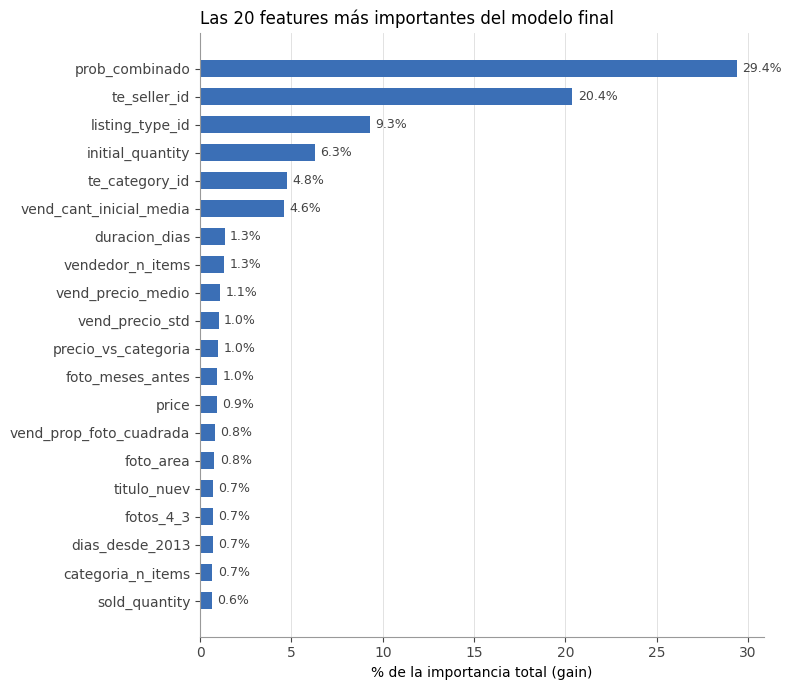

Las 20 primeras suman 87% de la importancia.
Las que menos aportan: tiene_tienda_oficial, pago_MLAVE, tag_poor_quality_thumbnail, pago_MLAMS, pago_MLAMC, tiene_precio_original, dif_precio_base, tiene_catalogo, n_deals, vend_n_ciudades


In [15]:
importancia = pd.Series(modelo.booster_.feature_importance("gain"), index=A.columns)
importancia = (importancia / importancia.sum()).sort_values(ascending=False)

top = importancia.head(20)[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top.values * 100, color="#3B6FB6", height=0.6)
for i, v in enumerate(top.values * 100):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9, color="#444")
ax.set_xlabel("% de la importancia total (gain)")
ax.set_title("Las 20 features más importantes del modelo final", loc="left")
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
ax.spines["left"].set_color("#999"); ax.spines["bottom"].set_color("#999")
ax.tick_params(colors="#444")
ax.grid(axis="x", color="#ddd", linewidth=0.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Las 20 primeras suman {importancia.head(20).sum():.0%} de la importancia.")
print("Las que menos aportan:", ", ".join(importancia.tail(10).index))